# Module 12 Dispatch Calibration Validation

This notebook compares the Module 12 structural baseline against the EAF-calibrated solve using only canonical repository outputs. The structural baseline is the first `NoCO2-1H` no-EAF solve after Sasol removal, `other_re` removal, and corrected PHS duration. It is not a stock PyPSA-Earth baseline.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    import pypsa
except Exception as exc:
    pypsa = None
    print(f"PyPSA unavailable: {exc}")

ROOT = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "Snakefile").exists()), Path.cwd())
RUN = "za_2023_fixed_validation"
RESULTS = ROOT / "results" / RUN / "networks"
FIG_DIR = ROOT / "doc" / "za_validation" / "figures" / "12_dispatch_calibration"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ESKOM = ROOT / "data" / "za_validation" / "eskom_2023_hourly_clean.csv"
# Module 12 — `lc1` (cost-limit factor 1.0) locks transmission to 2023 fixed
# grid. `lcopt` previously enabled unbounded line expansion (~+220 MW).
STRUCTURAL_NET = RESULTS / "elec_s_34_ec_lc1_NoCO2-1H.nc"
EAF_CANDIDATES = [
    RESULTS / "elec_s_34_ec_lc1_NoCO2-1H-EAF.nc",
    RESULTS / "elec_s_34_ec_lc1_NoCO2-1H_eaf.nc",
    RESULTS / "elec_s_34_ec_lc1_NoCO2-1H.calibrated.nc",
]
EAF_NET = next((p for p in EAF_CANDIDATES if p.exists()), EAF_CANDIDATES[0])

paths = pd.DataFrame([
    {"artifact": "Eskom hourly clean", "path": ESKOM, "exists": ESKOM.exists()},
    {"artifact": "Module 12 structural baseline", "path": STRUCTURAL_NET, "exists": STRUCTURAL_NET.exists()},
    {"artifact": "EAF-calibrated solve", "path": EAF_NET, "exists": EAF_NET.exists()},
])
paths


Matplotlib is building the font cache; this may take a moment.


,artifact,path,exists
0,Eskom hourly clean,/Users/nylan/Documents/BSE/Reliable-Electrific...,True
1,Module 12 structural baseline,/Users/nylan/Documents/BSE/Reliable-Electrific...,True
2,EAF-calibrated solve,/Users/nylan/Documents/BSE/Reliable-Electrific...,False


In [2]:
if not ESKOM.exists():
    raise FileNotFoundError(f"Missing canonical Eskom hourly file: {ESKOM}")

eskom = pd.read_csv(ESKOM, index_col=0, parse_dates=True).sort_index()
print(f"Eskom rows: {len(eskom):,}; range: {eskom.index.min()} -> {eskom.index.max()}")


Eskom rows: 8,760; range: 2023-01-01 00:00:00 -> 2023-12-31 23:00:00


In [3]:
def load_network(path: Path):
    if pypsa is None or not path.exists():
        return None
    return pypsa.Network(str(path))

def zero(index):
    return pd.Series(0.0, index=index)

def gen_dispatch(net, carriers):
    gens = net.generators[net.generators.carrier.isin(carriers)].index
    if len(gens) == 0 or net.generators_t.p.empty:
        return zero(net.snapshots)
    return net.generators_t.p[gens].sum(axis=1)

def storage_dispatch(net, carrier, mode="discharge"):
    """Module 12 — sign convention for storage_units_t.p (single signed series):
        positive = discharge (generation), negative = charge (pumping).
    mode="discharge" returns positive generation; mode="pumping" returns
    positive *consumption* (so both sides of the PHS comparison can be on the
    same sign); mode="net" returns the raw signed series.
    """
    units = net.storage_units[net.storage_units.carrier == carrier].index
    if len(units) == 0 or net.storage_units_t.p.empty:
        return zero(net.snapshots)
    p = net.storage_units_t.p[units].sum(axis=1)
    if mode == "discharge":
        return p.clip(lower=0)
    if mode in ("pumping", "charge"):
        return (-p).clip(lower=0)
    return p

def csp_link_dispatch(net):
    """CSP electric output flows through the advanced-CSP Link (carrier=='csp').

    The CSP Generator on the `X csp` bus represents solar field collection; the
    Link converts collected energy into electricity at the parent bus. Reading
    the Generator's `p` here would double-count or miss TES-shifted dispatch.
    Falls back to Generator dispatch if no CSP Link exists.
    """
    if len(net.links) and (net.links.carrier == "csp").any():
        csp_links = net.links[net.links.carrier == "csp"].index
        if not net.links_t.p0.empty:
            return net.links_t.p0[csp_links].sum(axis=1).clip(lower=0)
    return gen_dispatch(net, ["csp"])

def model_timeseries(net):
    idx = net.snapshots
    return pd.DataFrame({
        "coal": gen_dispatch(net, ["coal"]),
        "nuclear": gen_dispatch(net, ["nuclear"]),
        "ocgt": gen_dispatch(net, ["ocgt_diesel", "ocgt_gas"]),
        "hydro": storage_dispatch(net, "hydro", "discharge"),
        "phs_generation": storage_dispatch(net, "PHS", "discharge"),
        "phs_pumping": storage_dispatch(net, "PHS", "pumping"),
        "wind": gen_dispatch(net, ["onwind"]),
        "solar_pv": gen_dispatch(net, ["solar"]),
        "csp": csp_link_dispatch(net),
        "load_shedding": gen_dispatch(net, ["load shedding"]),
    }, index=idx)

def eskom_timeseries(index):
    e = eskom.reindex(index)
    out = pd.DataFrame(index=index)
    out["coal"] = e.get("Thermal Generation", 0.0)
    out["nuclear"] = e.get("Nuclear Generation", 0.0)
    out["ocgt"] = e.get("Eskom OCGT Generation", 0.0) + e.get("Dispatchable IPP OCGT", 0.0)
    out["hydro"] = e.get("Hydro Water Generation", 0.0)
    out["phs_generation"] = e.get("Pumped Water Generation", 0.0)
    # Module 12 — Eskom Pumped Water SCO Pumping is reported as consumption.
    # Force positive convention so it matches the model `pumping` mode above.
    phs_pump = e.get("Pumped Water SCO Pumping", 0.0)
    out["phs_pumping"] = phs_pump.abs() if hasattr(phs_pump, "abs") else abs(phs_pump)
    out["wind"] = e.get("Wind", 0.0)
    out["solar_pv"] = e.get("PV", 0.0)
    out["csp"] = e.get("CSP", 0.0)
    out["load_shedding"] = (
        e.get("Manual Load_Reduction(MLR)", 0.0)
        + e.get("ILS Usage", 0.0)
        + e.get("IOS Excl ILS and MLR", 0.0)
    )
    return out.fillna(0.0)

def summarise(model, reference, label, window=None):
    if window == "july":
        model = model.loc["2023-07-01":"2023-07-31"]
        reference = reference.loc[model.index]
    rows = []
    for carrier in model.columns:
        m = float(model[carrier].sum() / 1e3)
        r = float(reference[carrier].sum() / 1e3)
        rows.append({
            "solve": label,
            "window": window or "annual",
            "carrier": carrier,
            "model_gwh": m,
            "eskom_gwh": r,
            "delta_gwh": m - r,
            "delta_pct": ((m - r) / r * 100.0) if abs(r) > 1e-9 else np.nan,
        })
    return pd.DataFrame(rows)


In [4]:
net_struct = load_network(STRUCTURAL_NET)
net_eaf = load_network(EAF_NET)

status = pd.DataFrame([
    {"solve": "structural", "path": STRUCTURAL_NET, "loaded": net_struct is not None},
    {"solve": "eaf_calibrated", "path": EAF_NET, "loaded": net_eaf is not None},
])
status


INFO:pypsa.io:Imported network elec_s_34_ec_lc1_NoCO2-1H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


,solve,path,loaded
0,structural,/Users/nylan/Documents/BSE/Reliable-Electrific...,True
1,eaf_calibrated,/Users/nylan/Documents/BSE/Reliable-Electrific...,False


In [5]:
summaries = []
series = {}

for label, net in [("structural", net_struct), ("eaf_calibrated", net_eaf)]:
    if net is None:
        continue
    model = model_timeseries(net)
    reference = eskom_timeseries(model.index)
    series[label] = (model, reference)
    summaries.append(summarise(model, reference, label))
    summaries.append(summarise(model, reference, label, window="july"))

summary = pd.concat(summaries, ignore_index=True) if summaries else pd.DataFrame(
    columns=["solve", "window", "carrier", "model_gwh", "eskom_gwh", "delta_gwh", "delta_pct"]
)
summary_path = ROOT / "data" / "za_validation" / "za_2023_dispatch_calibration_before_after.csv"
summary_path.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(summary_path, index=False)
summary


,solve,window,carrier,model_gwh,eskom_gwh,delta_gwh,delta_pct
0,structural,annual,coal,193879.493366,165626.914379,28252.578987,17.057964
1,structural,annual,nuclear,8672.714999,8126.615558,546.099441,6.719888
2,structural,annual,ocgt,7042.738233,5243.134548,1799.603685,34.323050
3,structural,annual,hydro,1286.724266,1991.804788,-705.080522,-35.399078
4,structural,annual,phs_generation,821.481852,4294.480734,-3472.998882,-80.871218
5,structural,annual,phs_pumping,1095.309920,5657.906250,-4562.596330,-80.641073
6,structural,annual,wind,7312.140136,11613.363923,-4301.223787,-37.036847
7,structural,annual,solar_pv,3625.490117,5014.844853,-1389.354736,-27.704840
8,structural,annual,csp,805.537178,1375.348702,-569.811524,-41.430331
9,structural,annual,load_shedding,0.102285,16755.306947,-16755.204662,-99.999390


In [6]:
constraints = pd.DataFrame([
    {
        "constraint": "structural_baseline",
        "status": "defined",
        "source": "Module 12 plan",
        "notes": "No CO2 cap, no Sasol, no other_re, corrected PHS duration, no coal EAF.",
    },
    {
        "constraint": "coal_eaf",
        "status": "pending" if net_eaf is None else "applied_or_external",
        "source": "Must be logged before calibrated solve is accepted",
        "notes": "Cleaned Eskom PCLF/UCLF+OCLF are system-wide; use documented carrier/station source before treating as coal EAF.",
    },
])
constraints_path = ROOT / "data" / "za_validation" / "za_2023_dispatch_calibration_constraints.csv"
constraints.to_csv(constraints_path, index=False)
constraints


,constraint,status,source,notes
0,structural_baseline,defined,Module 12 plan,"No CO2 cap, no Sasol, no other_re, corrected P..."
1,coal_eaf,pending,Must be logged before calibrated solve is acce...,Cleaned Eskom PCLF/UCLF+OCLF are system-wide; ...


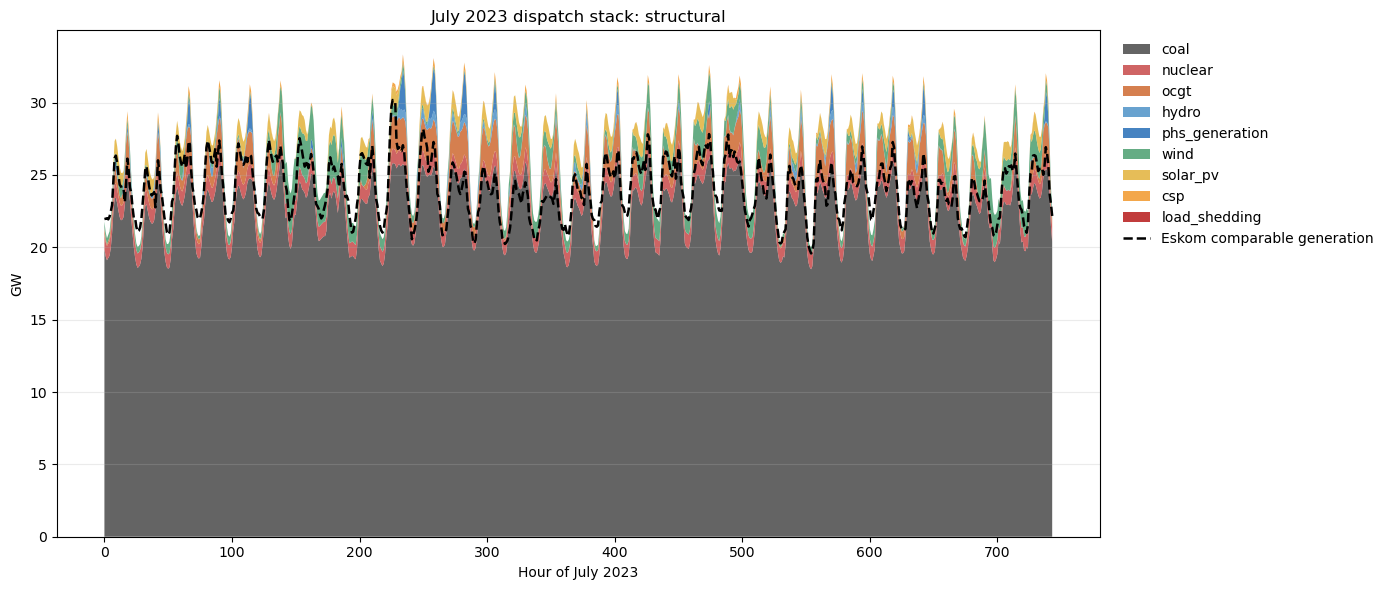

[PosixPath('/Users/nylan/Documents/BSE/Reliable-Electrification-Planning-SA-Vault/6-codebases/repos/pypsa-earth/doc/za_validation/figures/12_dispatch_calibration/july_dispatch_stack_structural.png')]

In [7]:
def plot_july_stack(label):
    if label not in series:
        return None
    model, reference = series[label]
    july = model.loc["2023-07-01":"2023-07-31"].copy() / 1e3
    ref = reference.loc[july.index]
    order = ["coal", "nuclear", "ocgt", "hydro", "phs_generation", "wind", "solar_pv", "csp", "load_shedding"]
    order = [c for c in order if c in july.columns and july[c].abs().sum() > 1e-6]
    colors = {
        "coal": "#4b4b4b", "nuclear": "#c84a4a", "ocgt": "#cf6a32",
        "hydro": "#4f93c7", "phs_generation": "#276fb7", "wind": "#4c9f70",
        "solar_pv": "#e2b33c", "csp": "#f1992d", "load_shedding": "#b71c1c",
    }
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(july))
    ax.stackplot(x, [july[c].values for c in order], labels=order, colors=[colors.get(c, "#999999") for c in order], alpha=0.86)
    ax.plot(x, ref[["coal", "nuclear", "ocgt", "hydro", "phs_generation", "wind", "solar_pv", "csp"]].sum(axis=1).values / 1e3, color="black", lw=1.8, ls="--", label="Eskom comparable generation")
    ax.set_title(f"July 2023 dispatch stack: {label}")
    ax.set_ylabel("GW")
    ax.set_xlabel("Hour of July 2023")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
    fig.tight_layout()
    out = FIG_DIR / f"july_dispatch_stack_{label}.png"
    fig.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    return out

written = [plot_july_stack(label) for label in ["structural", "eaf_calibrated"]]
[p for p in written if p is not None]


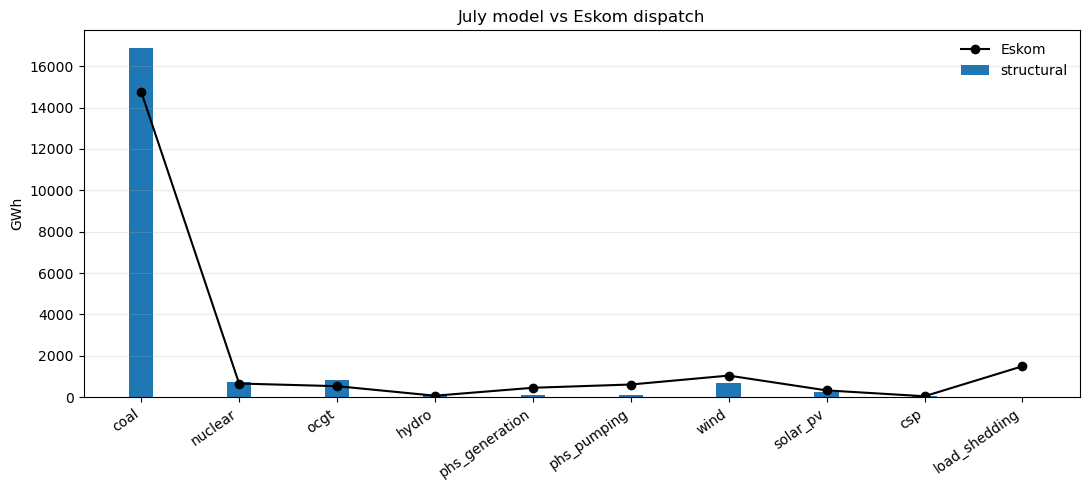

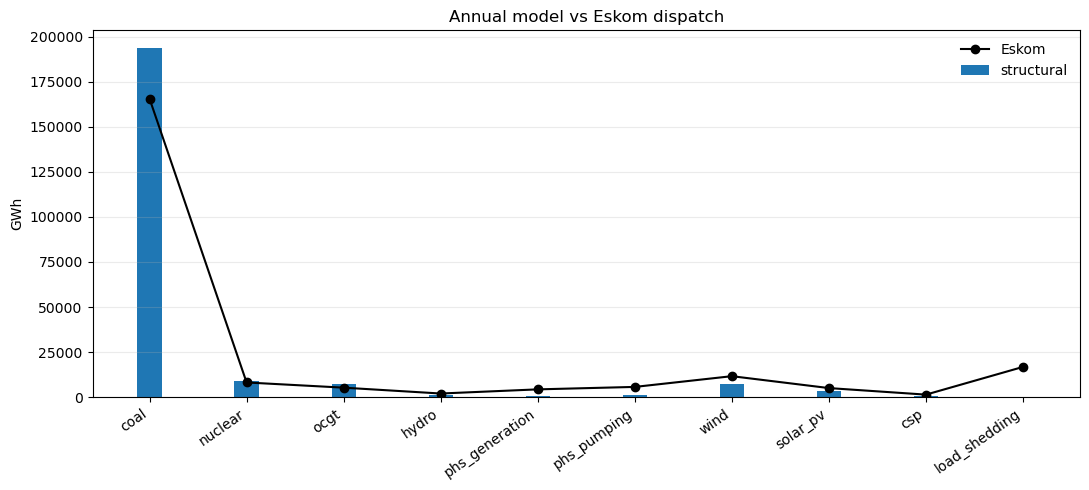

In [8]:
if not summary.empty:
    for window in ["july", "annual"]:
        frame = summary[summary["window"] == window]
        carriers = ["coal", "nuclear", "ocgt", "hydro", "phs_generation", "phs_pumping", "wind", "solar_pv", "csp", "load_shedding"]
        frame = frame[frame["carrier"].isin(carriers)]
        pivot = frame.pivot(index="carrier", columns="solve", values="model_gwh").reindex(carriers).dropna(how="all")
        ref = frame.groupby("carrier")["eskom_gwh"].first().reindex(pivot.index)
        fig, ax = plt.subplots(figsize=(11, 5))
        x = np.arange(len(pivot.index))
        width = 0.25
        solves = list(pivot.columns)
        for i, solve in enumerate(solves):
            ax.bar(x + (i - (len(solves)-1)/2) * width, pivot[solve], width, label=solve)
        ax.plot(x, ref.values, color="black", marker="o", lw=1.5, label="Eskom")
        ax.set_xticks(x)
        ax.set_xticklabels(pivot.index, rotation=35, ha="right")
        ax.set_ylabel("GWh")
        ax.set_title(f"{window.title()} model vs Eskom dispatch")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(frameon=False)
        fig.tight_layout()
        out = FIG_DIR / f"{window}_dispatch_comparison.png"
        fig.savefig(out, dpi=140, bbox_inches="tight")
        plt.show()
else:
    print("No canonical Module 12 netCDF outputs found yet; tables were written with pending status only.")


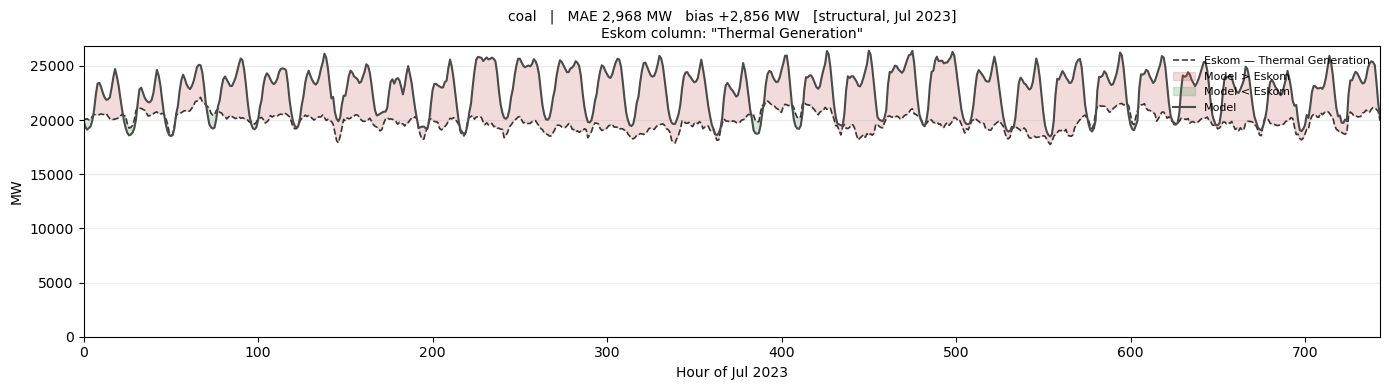

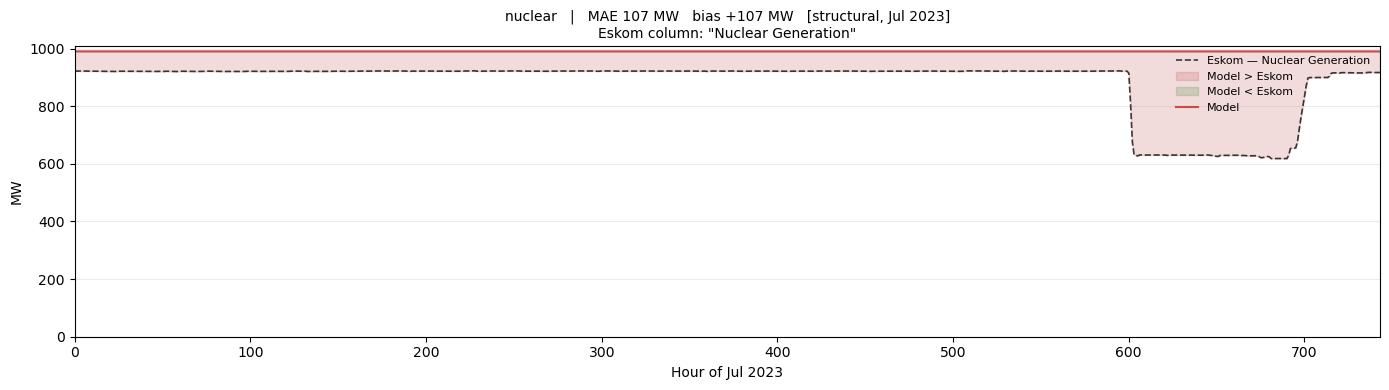

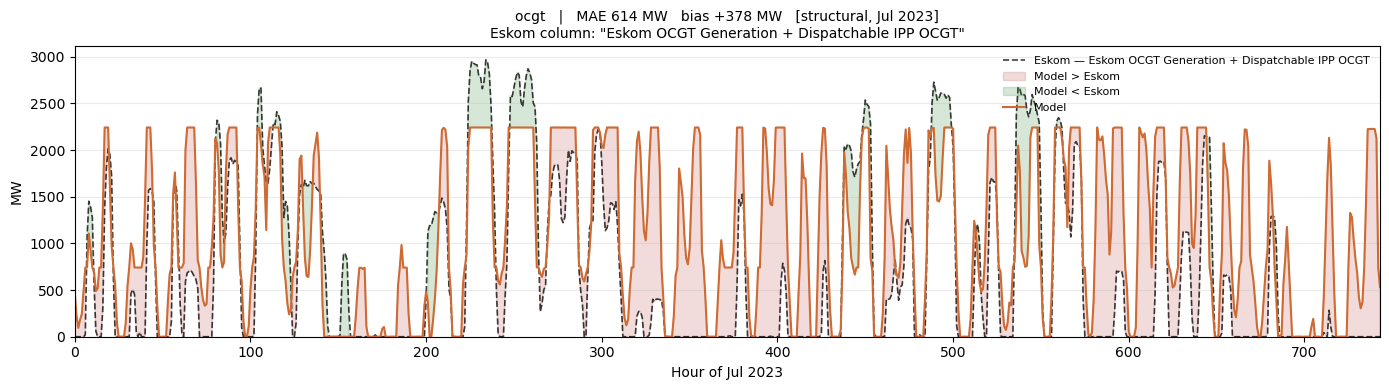

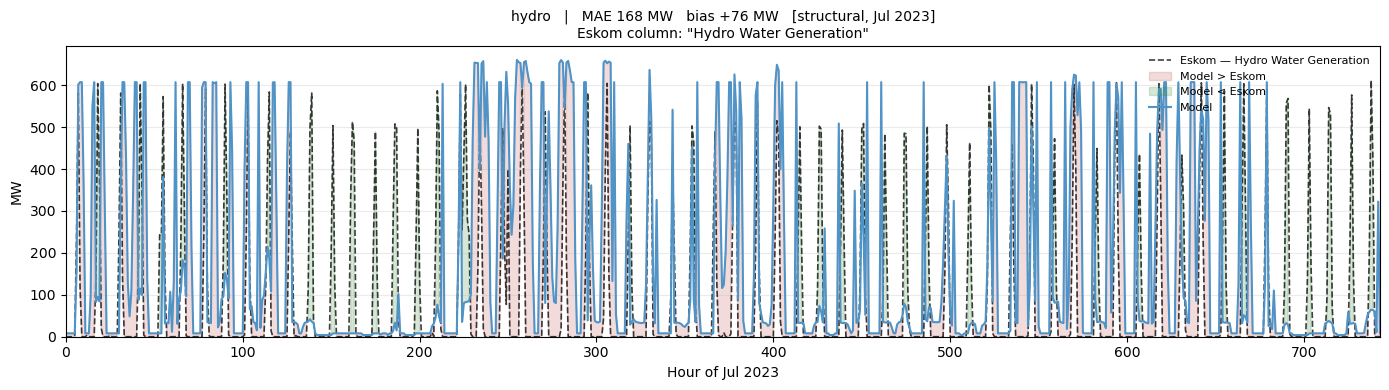

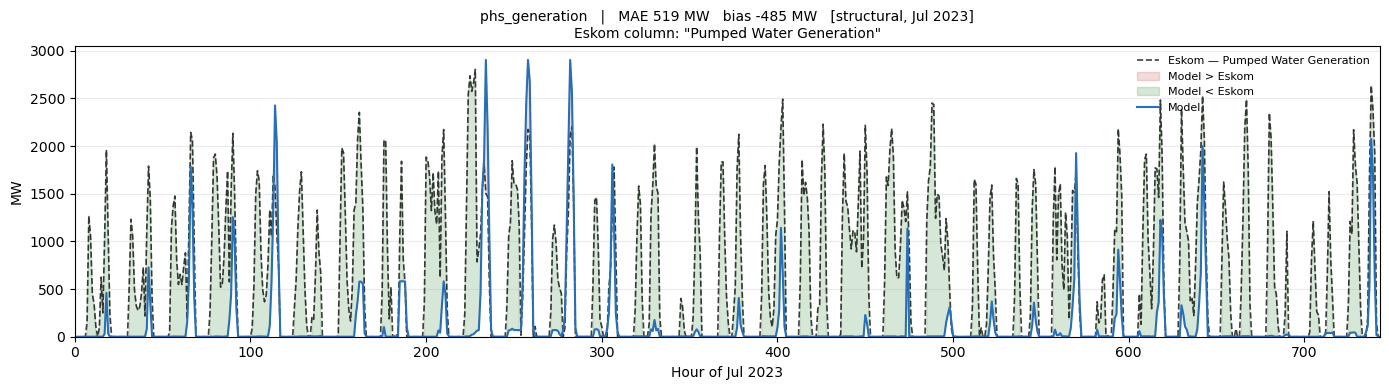

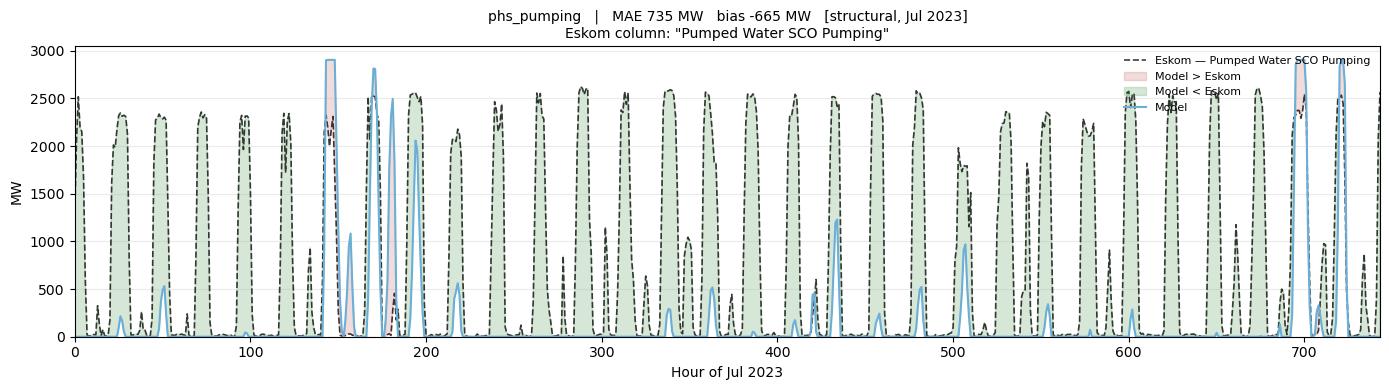

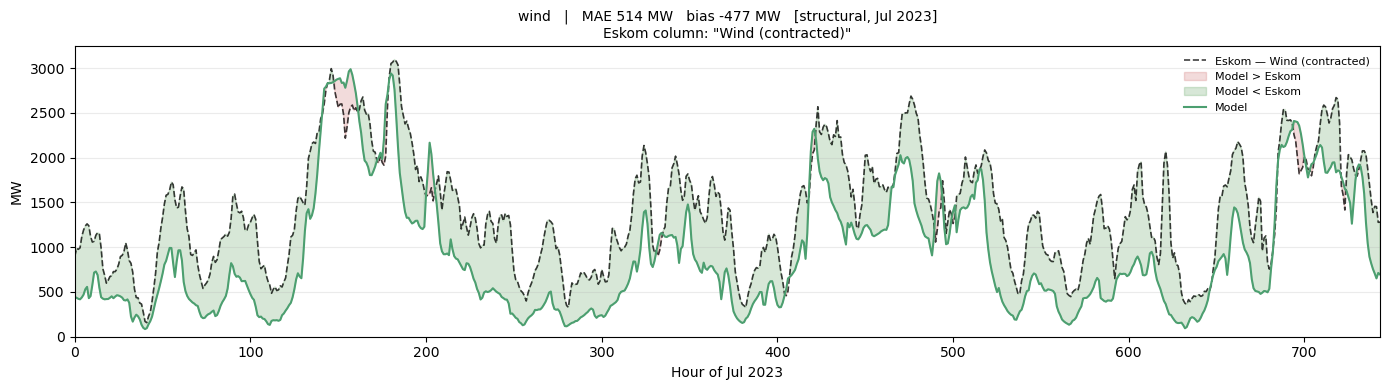

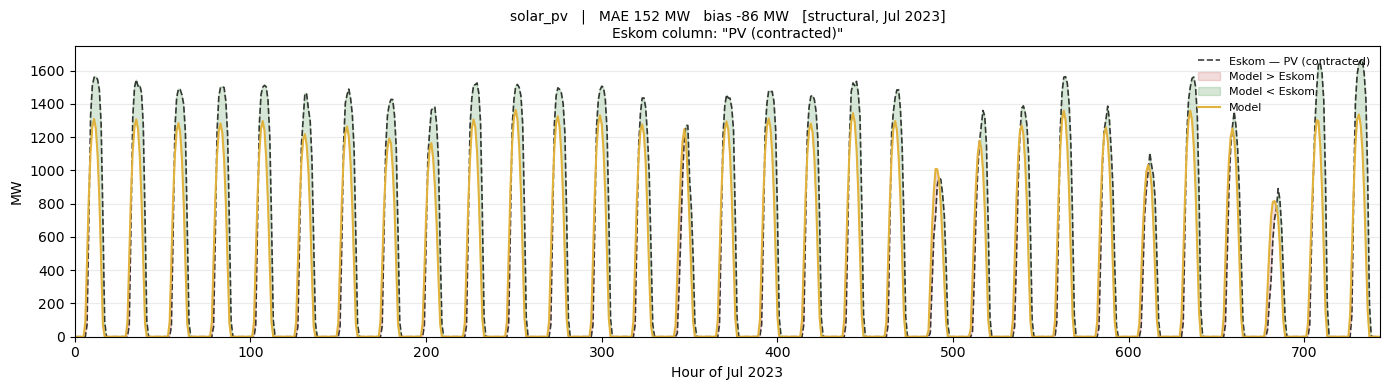

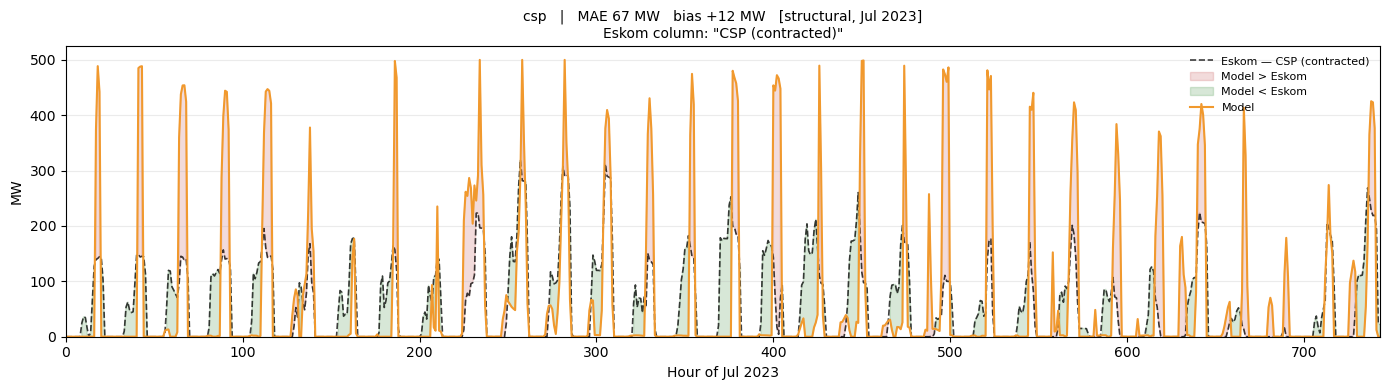

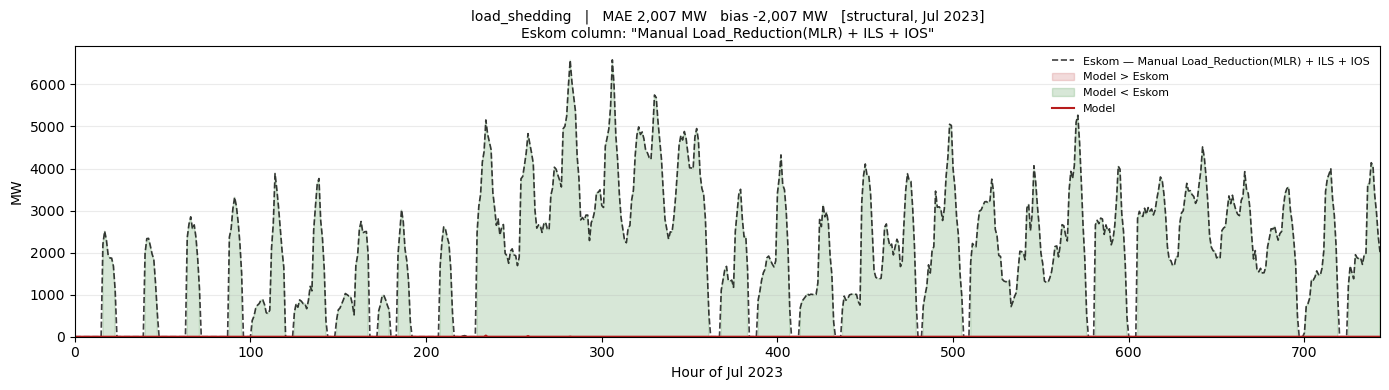


10 PNGs written to /Users/nylan/Documents/BSE/Reliable-Electrification-Planning-SA-Vault/6-codebases/repos/pypsa-earth/doc/za_validation/figures/12_dispatch_calibration


In [9]:
CARRIER_COLORS = {
    "coal": "#4b4b4b", "nuclear": "#c84a4a", "ocgt": "#cf6a32",
    "hydro": "#4f93c7", "phs_generation": "#276fb7", "phs_pumping": "#6baed6",
    "wind": "#4c9f70", "solar_pv": "#e2b33c", "csp": "#f1992d", "load_shedding": "#b71c1c",
}
CARRIERS = list(CARRIER_COLORS.keys())

ESKOM_LABELS = {
    "coal":          "Thermal Generation",
    "nuclear":       "Nuclear Generation",
    "ocgt":          "Eskom OCGT Generation + Dispatchable IPP OCGT",
    "hydro":         "Hydro Water Generation",
    "phs_generation":"Pumped Water Generation",
    "phs_pumping":   "Pumped Water SCO Pumping",
    "wind":          "Wind (contracted)",
    "solar_pv":      "PV (contracted)",
    "csp":           "CSP (contracted)",
    "load_shedding": "Manual Load_Reduction(MLR) + ILS + IOS",
}

def _subplot_grid(n, cols=4):
    rows = (n + cols - 1) // cols
    return rows, cols

# ── configurable ──────────────────────────────────────────────────────────────
REP_MONTH = 7   # 1=Jan … 12=Dec; change to any month to re-run
# ─────────────────────────────────────────────────────────────────────────────

import calendar
MONTH_LABEL = calendar.month_abbr[REP_MONTH]

written_hourly = []
for label, (model, reference) in series.items():
    m_slice = model[model.index.month == REP_MONTH]
    r_slice = reference.loc[m_slice.index]
    hours = np.arange(len(m_slice))

    for c in CARRIERS:
        m = m_slice[c].values
        e = r_slice[c].values
        mae  = np.mean(np.abs(m - e))
        bias = np.mean(m - e)

        fig, ax = plt.subplots(figsize=(14, 4))

        # Eskom reference — black dashed, behind
        ax.plot(hours, e, color="black", lw=1.2, ls="--", alpha=0.75,
                label=f"Eskom — {ESKOM_LABELS.get(c, c)}")

        # Coloured fill between curves
        ax.fill_between(hours, m, e,
                        where=(m > e), alpha=0.20, color="#c14b4b", label="Model > Eskom")
        ax.fill_between(hours, m, e,
                        where=(m < e), alpha=0.20, color="#3a8a3a", label="Model < Eskom")

        # Model — solid carrier colour on top
        ax.plot(hours, m, color=CARRIER_COLORS[c], lw=1.5, label="Model")

        ax.set_title(
            f"{c}   |   MAE {mae:,.0f} MW   bias {bias:+,.0f} MW   [{label}, {MONTH_LABEL} 2023]\n"
            f"Eskom column: \"{ESKOM_LABELS.get(c, c)}\"",
            fontsize=10,
        )
        ax.set_xlabel(f"Hour of {MONTH_LABEL} 2023")
        ax.set_ylabel("MW")
        ax.set_xlim(0, len(hours) - 1)
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=0.25)
        ax.legend(fontsize=8, frameon=False, loc="upper right")

        fig.tight_layout()
        out = FIG_DIR / f"hourly_{c}_{MONTH_LABEL.lower()}_{label}.png"
        fig.savefig(out, dpi=140, bbox_inches="tight")
        plt.show()
        written_hourly.append(out)

print(f"\n{len(written_hourly)} PNGs written to {FIG_DIR}")


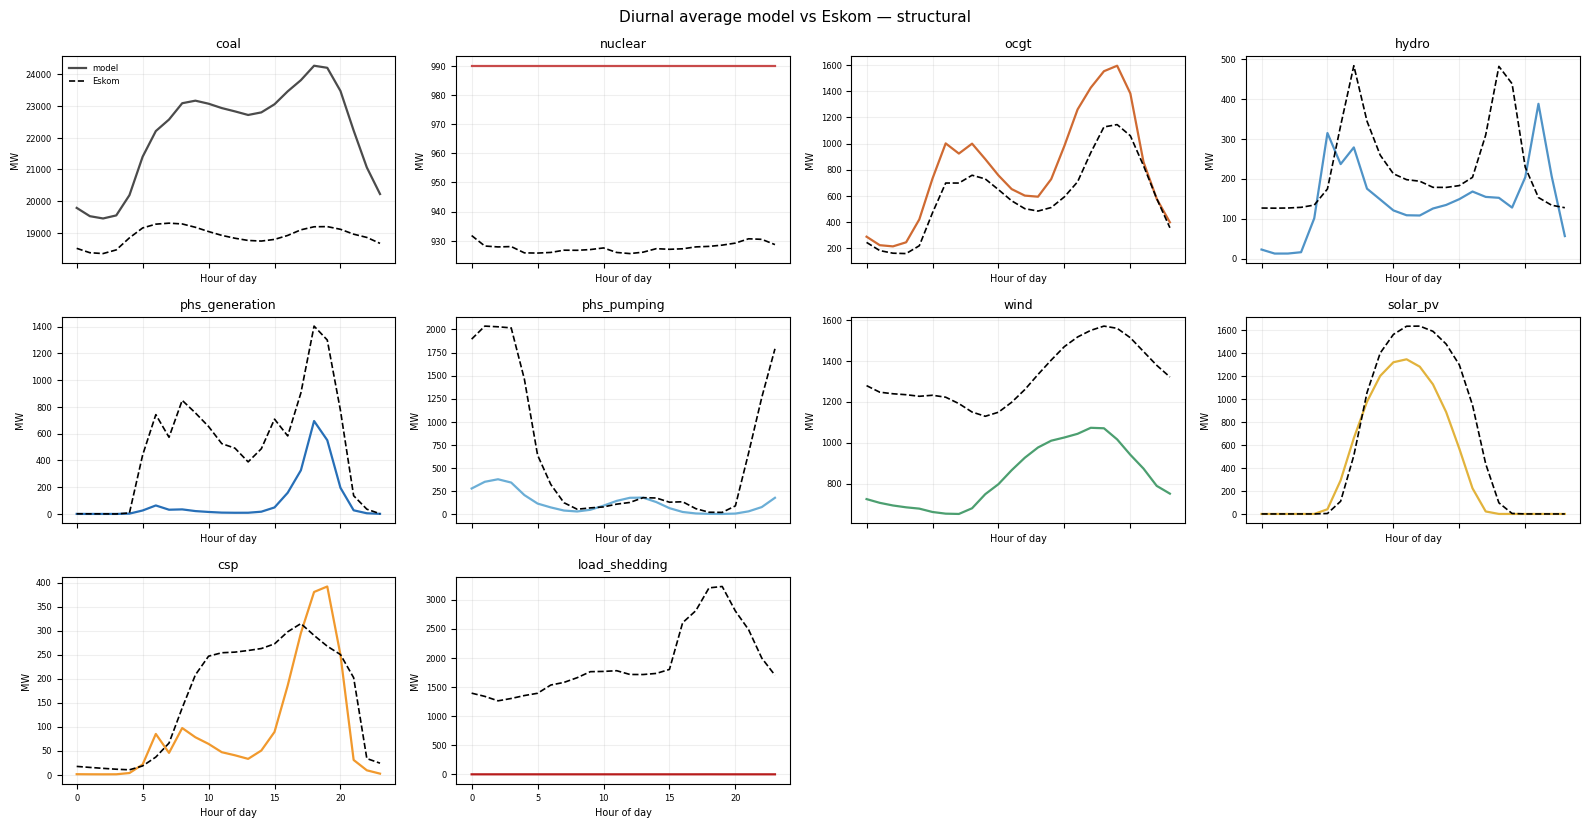

/Users/nylan/Documents/BSE/Reliable-Electrification-Planning-SA-Vault/6-codebases/repos/pypsa-earth/doc/za_validation/figures/12_dispatch_calibration/diurnal_average_carrier_structural.png


In [10]:
for label, (model, reference) in series.items():
    m_diurnal = model.groupby(model.index.hour).mean()
    r_diurnal = reference.groupby(reference.index.hour).mean()
    rows, cols = _subplot_grid(len(CARRIERS))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 2.8), sharex=True)
    axes_flat = axes.flatten()
    for i, c in enumerate(CARRIERS):
        ax = axes_flat[i]
        ax.plot(m_diurnal[c], color=CARRIER_COLORS[c], lw=1.6, label="model")
        ax.plot(r_diurnal[c], color="black", lw=1.2, ls="--", label="Eskom")
        ax.set_title(c, fontsize=9)
        ax.set_ylabel("MW", fontsize=7)
        ax.set_xlabel("Hour of day", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.2)
        if i == 0:
            ax.legend(fontsize=6, frameon=False)
    for j in range(len(CARRIERS), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(f"Diurnal average model vs Eskom — {label}", fontsize=11)
    fig.tight_layout()
    out = FIG_DIR / f"diurnal_average_carrier_{label}.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(out)


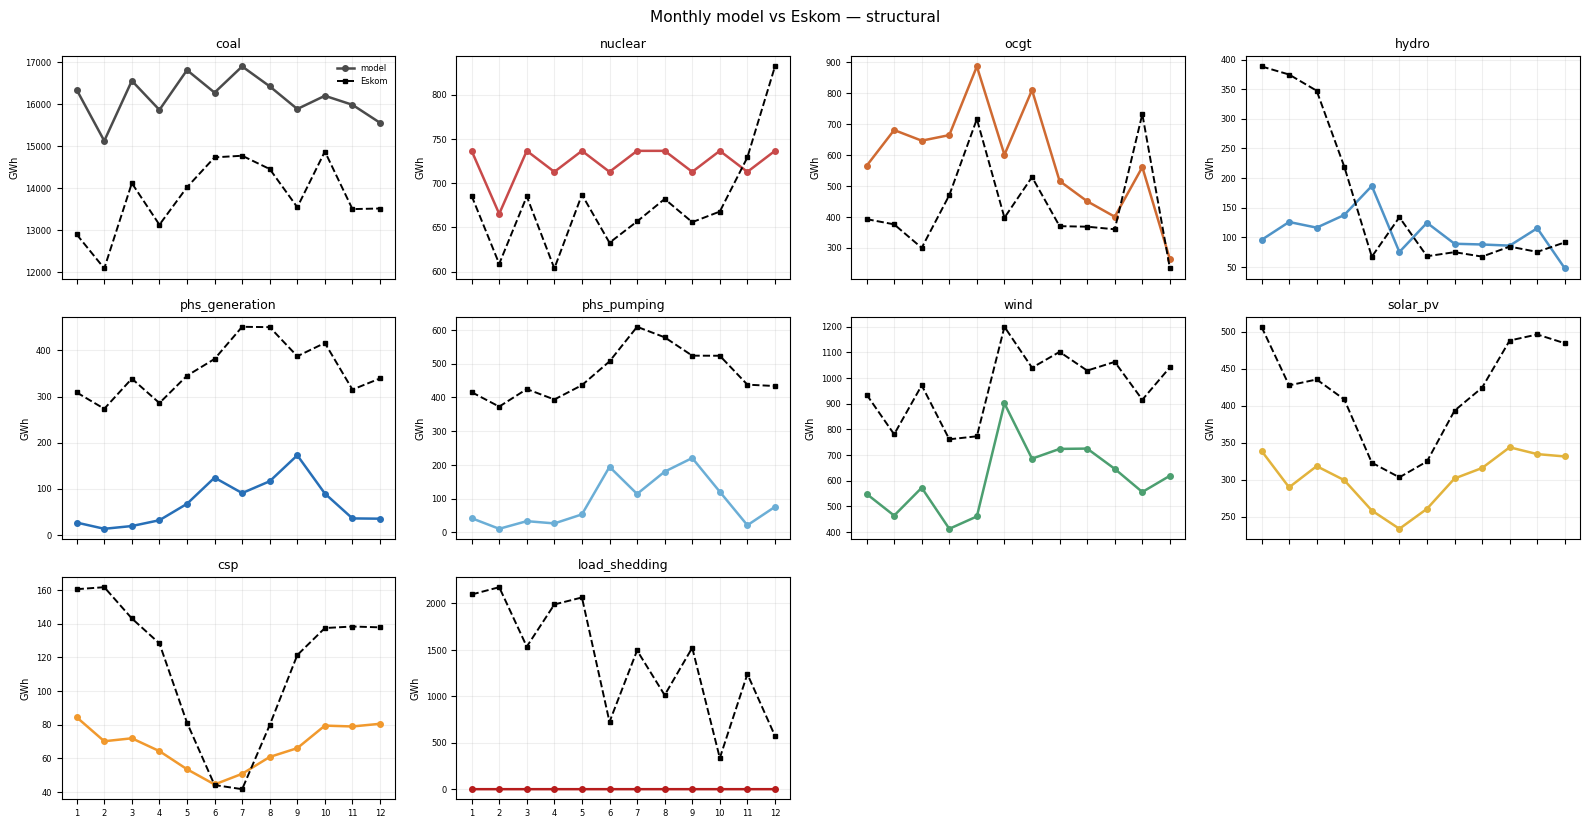

/Users/nylan/Documents/BSE/Reliable-Electrification-Planning-SA-Vault/6-codebases/repos/pypsa-earth/doc/za_validation/figures/12_dispatch_calibration/monthly_carrier_comparison_structural.png


In [11]:
for label, (model, reference) in series.items():
    m_monthly = model.resample("ME").sum() / 1e3   # GWh
    r_monthly = reference.resample("ME").sum() / 1e3
    months = np.arange(1, 13)
    rows, cols = _subplot_grid(len(CARRIERS))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 2.8), sharex=True)
    axes_flat = axes.flatten()
    for i, c in enumerate(CARRIERS):
        ax = axes_flat[i]
        mx = m_monthly[c].values if len(m_monthly) == 12 else np.full(12, np.nan)
        rx = r_monthly[c].values if len(r_monthly) == 12 else np.full(12, np.nan)
        ax.plot(months, mx, color=CARRIER_COLORS[c], lw=1.8, marker="o", ms=4, label="model")
        ax.plot(months, rx, color="black", lw=1.4, marker="s", ms=3, ls="--", label="Eskom")
        ax.set_title(c, fontsize=9)
        ax.set_ylabel("GWh", fontsize=7)
        ax.set_xticks(months)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.2)
        if i == 0:
            ax.legend(fontsize=6, frameon=False)
    for j in range(len(CARRIERS), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(f"Monthly model vs Eskom — {label}", fontsize=11)
    fig.tight_layout()
    out = FIG_DIR / f"monthly_carrier_comparison_{label}.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(out)


In [12]:
from scipy.stats import pearsonr

error_rows = []
for label, (model, reference) in series.items():
    # capacity factor denominator: max of model or eskom peak to avoid /0
    for c in CARRIERS:
        m = model[c].values.astype(float)
        r = reference[c].values.astype(float)
        mask = np.isfinite(m) & np.isfinite(r)
        m, r = m[mask], r[mask]
        rmse = float(np.sqrt(np.mean((m - r) ** 2)))
        mae = float(np.mean(np.abs(m - r)))
        bias = float(np.mean(m) - np.mean(r))
        corr = float(pearsonr(m, r)[0]) if m.std() > 0 and r.std() > 0 else np.nan
        peak = max(m.max(), r.max(), 1.0)
        cf_model = float(m.mean() / peak)
        cf_eskom = float(r.mean() / peak)
        error_rows.append({
            "solve": label, "carrier": c,
            "rmse_mw": rmse, "mae_mw": mae, "bias_mw": bias,
            "pearson_r": corr,
            "cf_model": cf_model, "cf_eskom": cf_eskom,
        })

errors_df = pd.DataFrame(error_rows)
err_path = ROOT / "data" / "za_validation" / "za_2023_dispatch_calibration_hourly_errors.csv"
errors_df.to_csv(err_path, index=False)
print(f"Saved: {err_path}\n")
print(errors_df[errors_df["solve"] == "structural"].set_index("carrier")
      [["rmse_mw", "mae_mw", "bias_mw", "pearson_r", "cf_model", "cf_eskom"]]
      .round({"rmse_mw": 1, "mae_mw": 1, "bias_mw": 1, "pearson_r": 3, "cf_model": 4, "cf_eskom": 4})
      .to_string())


Saved: /Users/nylan/Documents/BSE/Reliable-Electrification-Planning-SA-Vault/6-codebases/repos/pypsa-earth/data/za_validation/za_2023_dispatch_calibration_hourly_errors.csv

                rmse_mw  mae_mw  bias_mw  pearson_r  cf_model  cf_eskom
carrier                                                                
coal             3737.0  3269.2   3225.2      0.305    0.8348    0.7131
nuclear           176.4   112.9     62.3      0.055    0.5597    0.5245
ocgt              721.6   538.8    205.4      0.513    0.2710    0.2017
hydro             320.0   233.2    -80.5      0.088    0.2151    0.3329
phs_generation    677.1   427.0   -396.5      0.431    0.0323    0.1688
phs_pumping      1003.7   606.0   -520.8      0.273    0.0431    0.2224
wind              589.1   512.2   -491.0      0.864    0.2567    0.4077
solar_pv          329.5   202.6   -158.6      0.927    0.2021    0.2796
csp               172.3   116.8    -65.0      0.466    0.1818    0.3104
load_shedding    2418.4  1912.7  -

In [13]:
# Annual generation totals joined with hourly error metrics
for label in series:
    ann = summary[(summary["solve"] == label) & (summary["window"] == "annual")].set_index("carrier")
    err = errors_df[errors_df["solve"] == label].set_index("carrier")

    table = ann[["model_gwh", "eskom_gwh", "delta_gwh", "delta_pct"]].join(
        err[["rmse_mw", "mae_mw", "pearson_r"]]
    )
    table.columns = ["model_GWh", "eskom_GWh", "delta_GWh", "delta_%", "RMSE_MW", "MAE_MW", "r"]
    table = table.round({"model_GWh": 0, "eskom_GWh": 0, "delta_GWh": 0,
                         "delta_%": 1, "RMSE_MW": 0, "MAE_MW": 0, "r": 3})

    total_m = table["model_GWh"].sum()
    total_e = table["eskom_GWh"].sum()
    total_d = total_m - total_e
    totals = pd.DataFrame([{
        "model_GWh": round(total_m, 0), "eskom_GWh": round(total_e, 0),
        "delta_GWh": round(total_d, 0),
        "delta_%": round(total_d / total_e * 100, 1) if total_e else float("nan"),
        "RMSE_MW": "", "MAE_MW": "", "r": "",
    }], index=["TOTAL"])
    display_table = pd.concat([table, totals])

    print(f"\n=== Annual generation + hourly errors — {label} ===")
    print(display_table.to_string())



=== Annual generation + hourly errors — structural ===
                model_GWh  eskom_GWh  delta_GWh  delta_% RMSE_MW  MAE_MW      r
coal             193879.0   165627.0    28253.0     17.1  3737.0  3269.0  0.305
nuclear            8673.0     8127.0      546.0      6.7   176.0   113.0  0.055
ocgt               7043.0     5243.0     1800.0     34.3   722.0   539.0  0.513
hydro              1287.0     1992.0     -705.0    -35.4   320.0   233.0  0.088
phs_generation      821.0     4294.0    -3473.0    -80.9   677.0   427.0  0.431
phs_pumping        1095.0     5658.0    -4563.0    -80.6  1004.0   606.0  0.273
wind               7312.0    11613.0    -4301.0    -37.0   589.0   512.0  0.864
solar_pv           3625.0     5015.0    -1389.0    -27.7   329.0   203.0  0.927
csp                 806.0     1375.0     -570.0    -41.4   172.0   117.0  0.466
load_shedding         0.0    16755.0   -16755.0   -100.0  2418.0  1913.0  0.061
TOTAL            224541.0   225699.0    -1158.0     -0.5        

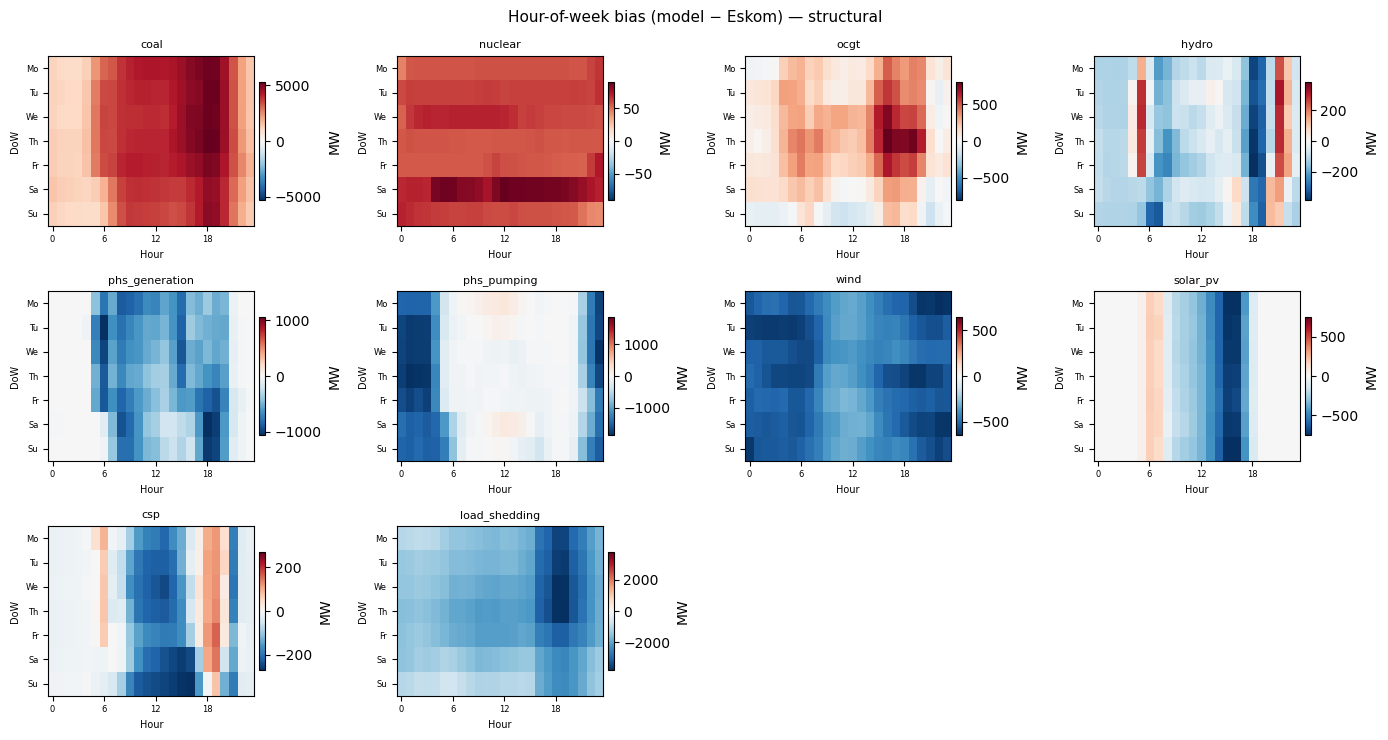

/Users/nylan/Documents/BSE/Reliable-Electrification-Planning-SA-Vault/6-codebases/repos/pypsa-earth/doc/za_validation/figures/12_dispatch_calibration/hour_of_week_heatmap_structural.png


In [14]:
for label, (model, reference) in series.items():
    diff = model.copy()
    for c in CARRIERS:
        diff[c] = model[c] - reference[c]
    diff["dow"] = diff.index.dayofweek   # 0=Mon
    diff["hour"] = diff.index.hour
    rows, cols = _subplot_grid(len(CARRIERS))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 2.5))
    axes_flat = axes.flatten()
    for i, c in enumerate(CARRIERS):
        ax = axes_flat[i]
        pivot = diff.groupby(["dow", "hour"])[c].mean().unstack(fill_value=0)
        vmax = np.abs(pivot.values).max() or 1.0
        im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r",
                       vmin=-vmax, vmax=vmax, origin="upper")
        ax.set_title(c, fontsize=8)
        ax.set_xlabel("Hour", fontsize=7)
        ax.set_ylabel("DoW", fontsize=7)
        ax.set_xticks(np.arange(0, 24, 6))
        ax.set_xticklabels([0, 6, 12, 18], fontsize=6)
        ax.set_yticks(np.arange(7))
        ax.set_yticklabels(["Mo","Tu","We","Th","Fr","Sa","Su"], fontsize=6)
        fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02, label="MW")
    for j in range(len(CARRIERS), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle(f"Hour-of-week bias (model − Eskom) — {label}", fontsize=11)
    fig.tight_layout()
    out = FIG_DIR / f"hour_of_week_heatmap_{label}.png"
    fig.savefig(out, dpi=130, bbox_inches="tight")
    plt.show()
    print(out)


In [15]:
def _csp_bus_completeness(net):
    """Return CSP bus-completeness details for positive CSP generator buses.

    Zero-capacity CSP buses are allowed. Every bus with positive CSP Generator
    p_nom must have its own fixed positive CSP Link p_nom and fixed positive
    CSP Store e_nom.
    """
    csp_gens = net.generators[(net.generators.carrier == "csp") & (net.generators.p_nom > 0)]
    gen_buses = set(csp_gens.bus.astype(str))

    csp_links = net.links[net.links.carrier == "csp"] if len(net.links) else net.links
    if len(csp_links):
        link_fixed = ~csp_links.p_nom_extendable if "p_nom_extendable" in csp_links.columns else True
        link_buses = set(csp_links[(csp_links.p_nom > 0) & link_fixed].bus0.astype(str))
    else:
        link_buses = set()

    csp_stores = net.stores[net.stores.carrier == "csp"] if len(net.stores) else net.stores
    if len(csp_stores):
        store_fixed = ~csp_stores.e_nom_extendable if "e_nom_extendable" in csp_stores.columns else True
        store_buses = set(csp_stores[(csp_stores.e_nom > 0) & store_fixed].bus.astype(str))
    else:
        store_buses = set()

    missing_link = sorted(gen_buses - link_buses)
    missing_store = sorted(gen_buses - store_buses)
    return {
        "positive_generator_buses": sorted(gen_buses),
        "missing_link_buses": missing_link,
        "missing_store_buses": missing_store,
    }


def _detail(values):
    if not values:
        return ""
    return "; ".join(values)


checks = []
for label, net in [("structural", net_struct), ("eaf_calibrated", net_eaf)]:
    if net is None:
        checks.append({"solve": label, "check": "network_exists", "status": "PENDING", "detail": ""})
        continue
    carriers = set(net.generators.carrier.astype(str))
    storage_carriers = set(net.storage_units.carrier.astype(str))
    csp = _csp_bus_completeness(net)
    checks.extend([
        {"solve": label, "check": "no_CO2Limit", "status": "PASS" if "CO2Limit" not in net.global_constraints.index else "FAIL", "detail": ""},
        {"solve": label, "check": "no_sasol_generators", "status": "PASS" if not any(c.startswith("sasol") for c in carriers) else "FAIL", "detail": ""},
        {"solve": label, "check": "no_other_re_generators", "status": "PASS" if "other_re" not in carriers else "FAIL", "detail": ""},
        {"solve": label, "check": "PHS_positive_max_hours", "status": "PASS" if (net.storage_units.loc[net.storage_units.carrier == "PHS", "max_hours"] > 0).all() else "FAIL", "detail": ""},
        {"solve": label, "check": "hydro_storage_units_present", "status": "PASS" if "hydro" in storage_carriers else "FAIL", "detail": ""},
        # Module 12 — fixed-grid expansion gate across ALL component classes.
        {"solve": label, "check": "no_extendable_generators", "status": "PASS" if not bool(net.generators.p_nom_extendable.any()) else "FAIL", "detail": ""},
        {"solve": label, "check": "no_extendable_storage_units", "status": "PASS" if not bool(net.storage_units.p_nom_extendable.any()) else "FAIL", "detail": ""},
        {"solve": label, "check": "no_extendable_stores", "status": "PASS" if (len(net.stores)==0 or not bool(net.stores.e_nom_extendable.any())) else "FAIL", "detail": ""},
        {"solve": label, "check": "no_extendable_links", "status": "PASS" if (len(net.links)==0 or not bool(net.links.p_nom_extendable.any())) else "FAIL", "detail": ""},
        {"solve": label, "check": "no_extendable_lines", "status": "PASS" if not bool(net.lines.s_nom_extendable.any()) else "FAIL", "detail": ""},
        {
            "solve": label,
            "check": "csp_link_p_nom_positive_bus_complete",
            "status": "PASS" if not csp["missing_link_buses"] else "FAIL",
            "detail": _detail(csp["missing_link_buses"]),
        },
        {
            "solve": label,
            "check": "csp_store_e_nom_positive_bus_complete",
            "status": "PASS" if not csp["missing_store_buses"] else "FAIL",
            "detail": _detail(csp["missing_store_buses"]),
        },
    ])
checks_df = pd.DataFrame(checks)
checks_df.to_csv(FIG_DIR / "module12_validation_checks.csv", index=False)
checks_df


,solve,check,status,detail
0,structural,no_CO2Limit,PASS,
1,structural,no_sasol_generators,PASS,
2,structural,no_other_re_generators,PASS,
3,structural,PHS_positive_max_hours,PASS,
4,structural,hydro_storage_units_present,PASS,
5,structural,no_extendable_generators,PASS,
6,structural,no_extendable_storage_units,PASS,
7,structural,no_extendable_stores,PASS,
8,structural,no_extendable_links,PASS,
9,structural,no_extendable_lines,PASS,
